# Early tests: seeds, centred rotation, and initialisation scale

This notebook runs the three tests chosen after the first results in `sam_ntk_tests.ipynb`. The training loop and the plot helpers now live in `ntk_lib.py` in this folder, which imports the dataset, model, kernel and alignment code from `RepoducedCode.py`. Compared with the first notebook the loop records two more quantities. The scale and rotation terms are computed on the centred kernel H K H as well as on the raw kernel, because the proposal defines them on the centred kernel and the script computes them on the raw one. The weight norm is recorded so it can be compared with Kumar et al. (2024), Figure 2(a). The probe kernel is also saved every 5,000 steps.

The three tests are as follows. First, five seeds at the baseline cell, to get the spread of the grokking time and of the alignment at the test crossing. Second, the centred scale and rotation terms against the raw ones on the same runs. Third, a sweep over the initialisation scale sigma, since Kumar et al., Appendix 8.2, state that sigma and alpha act through the product sigma squared times alpha, and their Figure 2(a) starts at a weight norm near 150 while standard normal weights on this architecture give about 83.

The baseline is the one from the first notebook. It is mean-field parameterisation with ReLU and no biases, width 100, p equal to 23, 90 percent of the pairs for training, mean squared error, full-batch gradient descent, base learning rate 10,000, alpha 1, and no weight decay. The thresholds for the grokking time are 0.003 on both losses, which is the provisional choice from the first notebook. Runs are 50,000 steps, since every crossing in the first notebook came before 25,000.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import ntk_lib as L
from ntk_lib import (run_or_load, grokking_time, format_time, value_at_step, peak_step,
                     plot_series, log_step_axis, mark_crossings, BLUE, ORANGE, AQUA, GRAY, RAMP)

torch.set_num_threads(4)
L.set_plot_style()

ETA_0 = 10000.0
STEPS = 50000
TAU_TRAIN = 3e-3
TAU_TEST = 3e-3
RERUN = False

def gt(run):
    return grokking_time(run, TAU_TRAIN, TAU_TEST)

## 1. Five seeds at the baseline

Each seed changes the model initialisation only. The data split is fixed by the data seed, so the five runs share one training set and one probe set.

In [2]:
SEEDS = [0, 1, 2, 3, 4]
seed_runs = [run_or_load(f"early_seed{s}", rerun=RERUN, seed=s, eta_0=ETA_0, steps=STEPS,
                         eval_interval=250) for s in SEEDS]
seed_g = [gt(r) for r in seed_runs]

print(f"{'seed':>4} {'t_train':>8} {'t_test':>7} {'t_grok':>7} {'A@test':>7} {'A peak':>7} {'peak step':>9} "
      f"{'R raw':>7} {'R cent':>7} {'S raw':>7} {'S cent':>7}")
rows = []
for s, r, g in zip(SEEDS, seed_runs, seed_g):
    if g["t_test"] is None:
        print(f"{s:>4} {str(g['t_train']):>8} {'-':>7} {format_time(g):>7}  censored")
        continue
    t = g["t_test"]
    row = dict(t_grok=g["t_grok"], A=value_at_step(r, "A_t", t), R=value_at_step(r, "R_t", t),
               Rc=value_at_step(r, "R_c", t), S=value_at_step(r, "S_t", t), Sc=value_at_step(r, "S_c", t))
    rows.append(row)
    print(f"{s:>4} {g['t_train']:>8} {t:>7} {g['t_grok']:>7} {row['A']:>7.4f} {max(r['history']['A_t']):>7.4f} "
          f"{peak_step(r, 'A_t'):>9} {row['R']:>7.4f} {row['Rc']:>7.4f} {row['S']:>+7.3f} {row['Sc']:>+7.3f}")
if rows:
    for key, label in [("t_grok", "grokking time"), ("A", "alignment at test crossing"),
                       ("Rc", "centred rotation at test crossing")]:
        vals = np.array([row[key] for row in rows])
        print(f"{label}: mean {vals.mean():.4g}, standard deviation {vals.std(ddof=1):.3g}, n = {len(vals)}")

early_seed0: loaded from results/early_seed0.json
early_seed1: loaded from results/early_seed1.json
early_seed2: loaded from results/early_seed2.json
early_seed3: loaded from results/early_seed3.json
early_seed4: loaded from results/early_seed4.json
seed  t_train  t_test  t_grok  A@test  A peak peak step   R raw  R cent   S raw  S cent
   0     5500   13000    7500  0.1275  0.1397      3250  0.0408  0.0798  +5.393  +5.514
   1     5000   12250    7250  0.1242  0.1347      3500  0.0398  0.0756  +5.355  +5.484
   2     5750   11750    6000  0.1244  0.1334      3000  0.0504  0.0810  +5.296  +5.480
   3     5000   10000    5000  0.1261  0.1388      3250  0.0437  0.0770  +5.334  +5.473
   4     5250   11000    5750  0.1258  0.1377      3250  0.0462  0.0810  +5.409  +5.545
grokking time: mean 6300, standard deviation 1.05e+03, n = 5
alignment at test crossing: mean 0.1256, standard deviation 0.00133, n = 5
centred rotation at test crossing: mean 0.07889, standard deviation 0.00246, n = 5


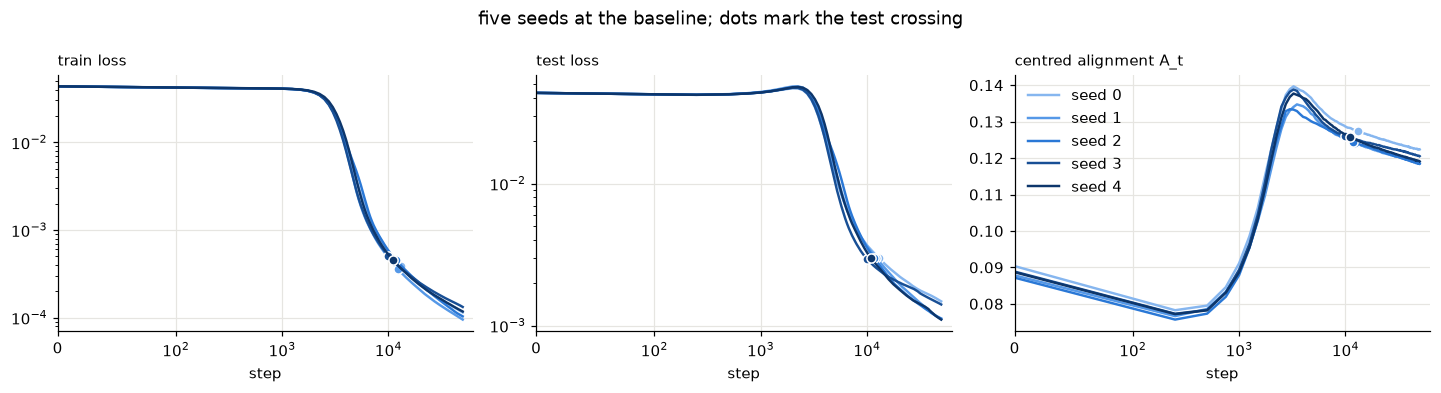

In [3]:
labels = [f"seed {s}" for s in SEEDS]
fig = plot_series(seed_runs, ["train_loss", "test_loss", "A_t"], labels, RAMP,
                  ["train loss", "test loss", "centred alignment A_t"],
                  log_y=("train_loss", "test_loss"), legend_panel=2, crossings=seed_g,
                  suptitle="five seeds at the baseline; dots mark the test crossing")

## 2. Centred against raw scale and rotation

The proposal defines the scale term, the rotation term and the alignment on the centred kernel. The raw kernel of a ReLU network on one-hot inputs has a large component that is the same for every pair of probe points. That component barely changes during training and it dominates the Frobenius inner product, so the raw rotation term can stay small while the eigenbasis of the centred kernel moves. The first panel compares the two scale terms, the second the two rotation terms, and the third the share of the squared relative movement that comes from rotation under each version.

largest difference between recorded and recomputed centred rotation over 11 saved kernels: 0.00e+00


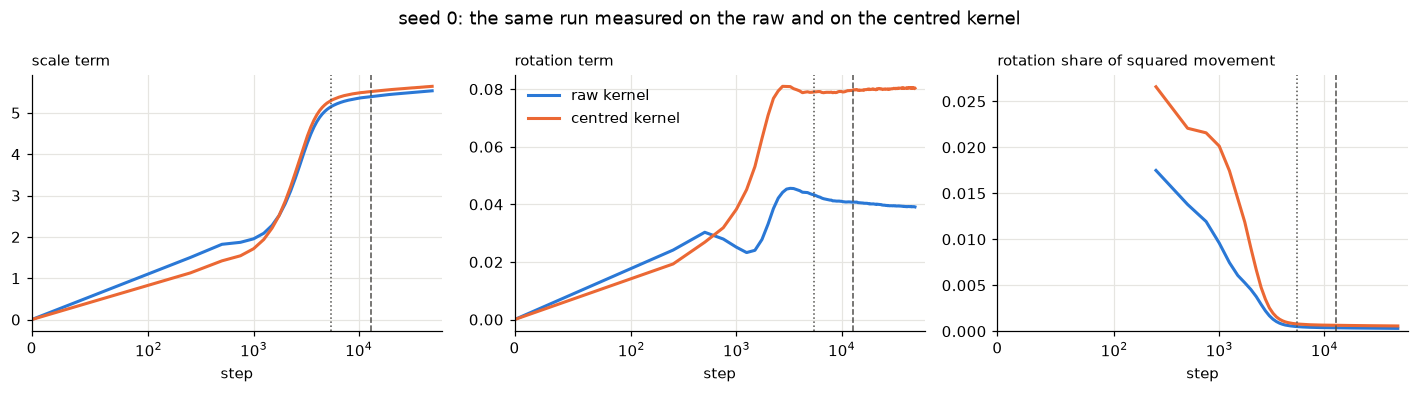

In [4]:
r0 = seed_runs[0]
h = r0["history"]
steps = np.asarray(h["step"])
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].plot(steps, h["S_t"], color=BLUE, label="raw kernel")
axes[0].plot(steps, h["S_c"], color=ORANGE, label="centred kernel")
axes[0].set_title("scale term", loc="left", fontsize=10)
axes[1].plot(steps, h["R_t"], color=BLUE, label="raw kernel")
axes[1].plot(steps, h["R_c"], color=ORANGE, label="centred kernel")
axes[1].set_title("rotation term", loc="left", fontsize=10)
for S, R, colour, label in [(h["S_t"], h["R_t"], BLUE, "raw kernel"), (h["S_c"], h["R_c"], ORANGE, "centred kernel")]:
    S, R = np.asarray(S), np.asarray(R)
    total = np.exp(2 * S) + 1 - 2 * np.exp(S) * (1 - R)
    share = np.where(total > 0, 2 * np.exp(S) * R / np.where(total > 0, total, 1), np.nan)
    axes[2].plot(steps, share, color=colour, label=label)
axes[2].set_title("rotation share of squared movement", loc="left", fontsize=10)
axes[2].set_ylim(0, None)
for ax in axes:
    ax.set_xlabel("step")
    log_step_axis(ax)
    mark_crossings(ax, seed_g[0])
axes[1].legend()
fig.suptitle("seed 0: the same run measured on the raw and on the centred kernel")
fig.tight_layout()

# Check the recorded centred terms against the saved kernels.
ks, K = L.load_kernels(r0["config"]["name"])
K0 = torch.tensor(K[0])
worst = 0.0
for st, Kt in zip(ks, K):
    Sc, Rc = L.compute_centred_scale_and_rotation(K0, torch.tensor(Kt))
    worst = max(worst, abs(Rc - value_at_step(r0, "R_c", int(st))))
print(f"largest difference between recorded and recomputed centred rotation over {len(ks)} saved kernels: {worst:.2e}")

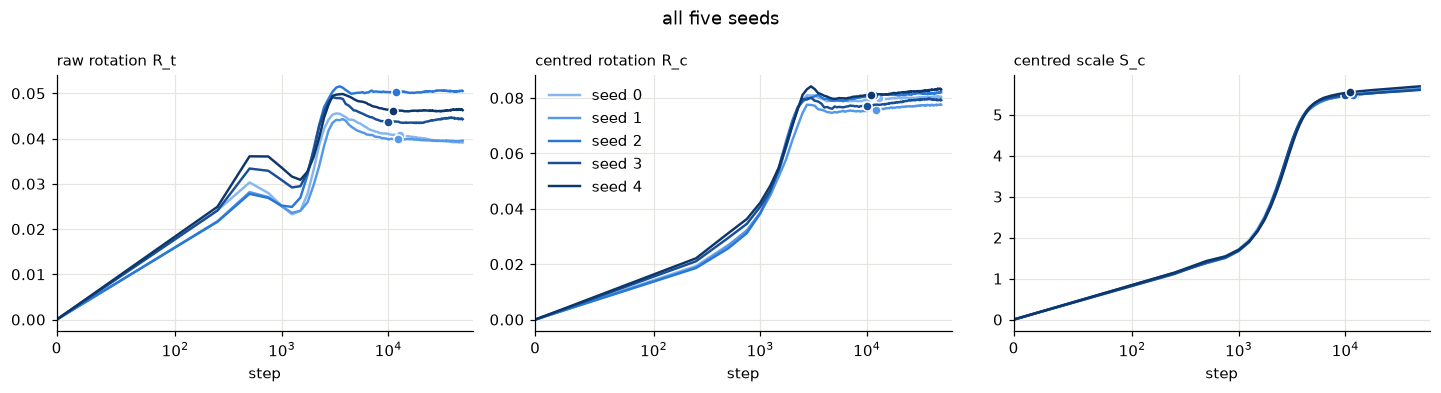

In [5]:
fig = plot_series(seed_runs, ["R_t", "R_c", "S_c"], labels, RAMP,
                  ["raw rotation R_t", "centred rotation R_c", "centred scale S_c"],
                  legend_panel=1, crossings=seed_g, suptitle="all five seeds")

## 3. Initialisation scale

The weights are drawn from a normal distribution with standard deviation sigma. Kumar et al. (2024), Appendix 8.2, report that the dynamics depend on sigma and alpha through sigma squared times alpha, so a larger sigma should act like a larger alpha and delay grokking. Their Figure 2(a) starts at a weight norm near 150, and on this architecture that corresponds to sigma near 1.8. The sigma equal to 1 run is seed 0 from Section 1.

In [6]:
SIGMAS = [0.5, 1.0, 1.8, 3.0]
sigma_runs = {}
for sg in SIGMAS:
    if sg == 1.0:
        sigma_runs[sg] = seed_runs[0]
    else:
        sigma_runs[sg] = run_or_load(f"early_sigma{sg:g}", rerun=RERUN, init_scale=sg, eta_0=ETA_0,
                                     steps=STEPS, eval_interval=250)
sigma_g = {sg: gt(sigma_runs[sg]) for sg in SIGMAS}

print(f"{'sigma':>5} {'w norm 0':>8} {'t_train':>8} {'t_test':>7} {'t_grok':>7} {'A@test':>7} {'A peak':>7} "
      f"{'R cent':>7} {'S cent':>7} {'S raw':>7}")
for sg in SIGMAS:
    r, g = sigma_runs[sg], sigma_g[sg]
    if g["t_test"] is None:
        print(f"{sg:>5g} {r['init_weight_norm']:>8.1f} {str(g['t_train']):>8} {'-':>7} {format_time(g):>7}  censored, "
              f"final test loss {r['history']['test_loss'][-1]:.2e}, A peak {max(r['history']['A_t']):.4f}")
        continue
    t = g["t_test"]
    print(f"{sg:>5g} {r['init_weight_norm']:>8.1f} {g['t_train']:>8} {t:>7} {g['t_grok']:>7} "
          f"{value_at_step(r, 'A_t', t):>7.4f} {max(r['history']['A_t']):>7.4f} "
          f"{value_at_step(r, 'R_c', t):>7.4f} {value_at_step(r, 'S_c', t):>+7.3f} {value_at_step(r, 'S_t', t):>+7.3f}")

early_sigma0.5: loaded from results/early_sigma0.5.json
early_sigma1.8: loaded from results/early_sigma1.8.json
early_sigma3: loaded from results/early_sigma3.json
sigma w norm 0  t_train  t_test  t_grok  A@test  A peak  R cent  S cent   S raw
  0.5     41.3     6000   11750    5750  0.1263  0.1377  0.0831  +6.905  +6.812
    1     82.5     5500   13000    7500  0.1275  0.1397  0.0798  +5.514  +5.393
  1.8    148.6     5000   13500    8500  0.1265  0.1386  0.0786  +4.351  +4.228
    3    247.6     5500   19500   14000  0.1204  0.1336  0.0803  +3.450  +3.339


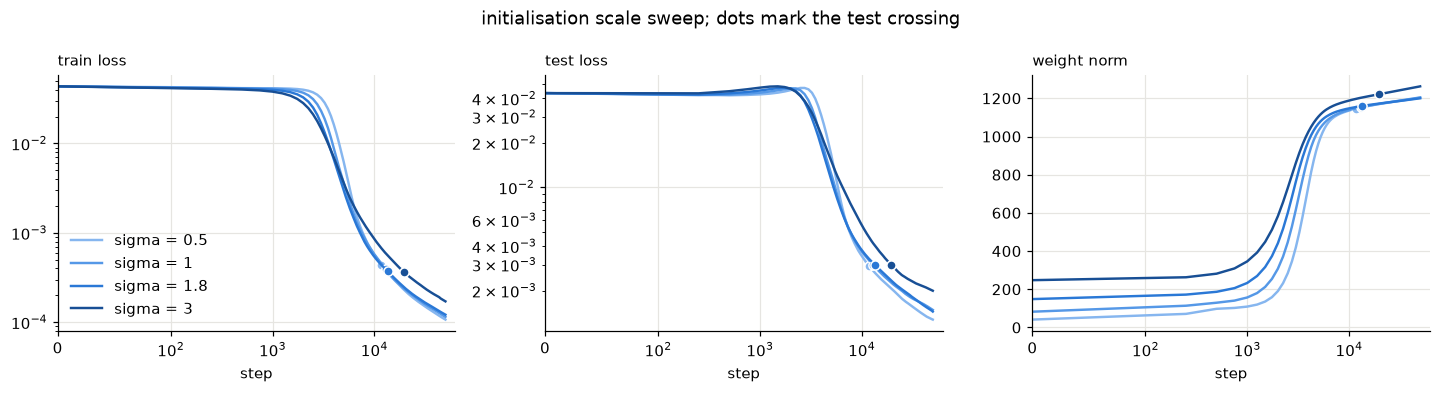

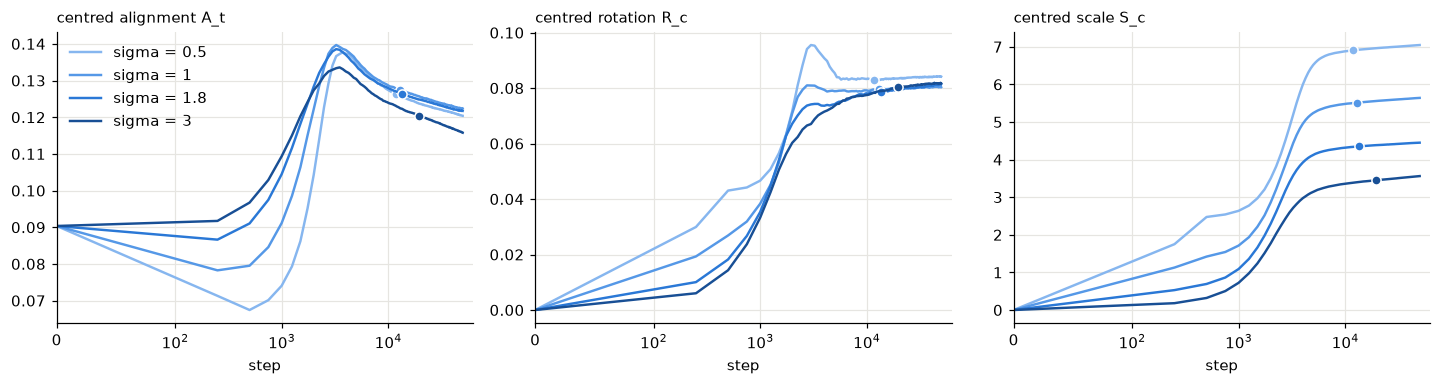

In [7]:
runs = [sigma_runs[sg] for sg in SIGMAS]
labels = [f"sigma = {sg:g}" for sg in SIGMAS]
crossings = [sigma_g[sg] for sg in SIGMAS]
fig = plot_series(runs, ["train_loss", "test_loss", "weight_norm"], labels, RAMP,
                  ["train loss", "test loss", "weight norm"],
                  log_y=("train_loss", "test_loss"), legend_panel=0, crossings=crossings,
                  suptitle="initialisation scale sweep; dots mark the test crossing")
fig = plot_series(runs, ["A_t", "R_c", "S_c"], labels, RAMP,
                  ["centred alignment A_t", "centred rotation R_c", "centred scale S_c"],
                  legend_panel=0, crossings=crossings)

## 4. Reading the results

These are the results of the run on 18 September 2026. The numbers are in the tables above.

**Seeds.** The grokking time at thresholds of 0.003 ranges from 5,000 to 7,500 steps over five seeds, with a mean of 6,300 and a standard deviation of about 1,050. The alignment at the test crossing is 0.1256 with a standard deviation of 0.0013, which is a spread of one percent while the grokking time spreads by seventeen percent. The centred rotation at the test crossing is 0.079 with a standard deviation of 0.0025. The alignment peaks between steps 3,000 and 3,500 in every seed, which is before the train crossing and roughly where the test accuracy jumps to one in the first notebook. The test crossing lands on the decline of the alignment. If the group keeps loss thresholds, the alignment at the crossing is a level on the falling side of the peak. The peak itself may be the better marker of the onset of generalisation, and both should be recorded.

**Centred against raw.** The recorded centred terms match the values recomputed from the saved kernels exactly. Centring changes the picture in two ways. The centred rotation term is about twice the raw one, near 0.08 against 0.04, and it rises monotonically to a plateau around step 3,000, where the raw term dips near step 1,000 and then recovers. The scale terms are almost the same on both kernels. The rotation share of the squared relative movement is below three percent at every checkpoint and below one tenth of a percent after step 3,000 on either kernel. So the conclusion of the first notebook stands after centring. In this regime the usual movement statistic is almost entirely scale, and the rotation term has to be read on its own rather than through that statistic.

**Initialisation scale.** The grokking time grows with sigma, from 5,750 at sigma 0.5 to 14,000 at sigma 3, which is the direction Kumar et al., Appendix 8.2, predict. At sigma 1.8 the initial weight norm is 149, which matches the start of their Figure 2(a), but the gap between the crossings is still about 8,500 steps, so matching the initial norm does not recover their long plateau. Their weight norm grows from about 150 to about 350 over the run, while ours grows from 149 to about 1,200. That factor of eight against a factor of a little over two is the clearest quantitative mismatch with the published figure so far, and it points at the learning rate or the loss normalisation rather than the initialisation. The alignment at the test crossing is between 0.120 and 0.128 across the four scales and the centred rotation at the crossing is between 0.079 and 0.083, while the centred scale at the crossing falls from 6.9 to 3.5. So the crossing happens at a nearly fixed alignment and rotation and at a scale that varies by a factor of thirty in the norm. That is the pattern hypothesis H predicts, from one width and one weight decay setting.

**What this changes in the plan.** The Tier 0 gate is still open, and the weight-norm growth is the number to match next, by testing the loss summed over the training set and a lower learning rate at the matched initial norm. The centred rotation term should replace the raw one in every later analysis, and the first notebook's rotation panels should be read as raw values. The alignment peak should be recorded alongside the crossing value in the Tier 1 grid.